# 4.  Ventilation study: statistical and dynamic-model analysis

This notebook contains only the analyses used in the manuscript. Each section answers one distinct question:

1. **Experimental effect:** does dorsal skin-temperature change differ between ventilation conditions within each protocol phase?
2. **Predictive comparison:** which reduced-order model better predicts held-out dorsal skin-temperature samples?
3. **Adaptation rate:** how does the identifiable exponential rate constant (k) vary across conditions and phases?

The analyses are deliberately kept separate. Output files from one section must not be combined with coefficients generated by another pipeline.


In [16]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import patsy
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.stats import chi2, norm
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from the current working directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Project root not found. Run the notebook inside the repository.")


def require_columns(df: pd.DataFrame, columns: list[str], name: str) -> None:
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


ROOT = find_project_root()
OUTPUT_DIR = ensure_dir(ROOT / "reports" / "06_statistics" / "final_analysis")

# Experimental phase analysis and Figure/Table 3 use this temporal dataset.
PHASE_DATA_PATH = ROOT / "data" / "processed" / "analysis" / "analysis_dataset_wide.csv"

# Dynamic models require the microclimate-temperature signal available here.
DYNAMIC_DATA_PATH = ROOT / "data" / "processed" / "features" / "analysis_dataset_with_tsk.csv"

SUBJECT_COL = "subject_id"
CONDITION_COL = "condition"
PHASE_COL = "phase"
TIME_COL = "elapsed_seconds"
T_DORSAL_COL = "t_dorsal"
T_MICRO_COL = "t_microclimateback"

CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]
PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]

CONDITION_LABELS = {
    "no_wind": "No ventilation",
    "wind_low": "Low ventilation",
    "wind_high": "High ventilation",
}
PHASE_LABELS = {
    "standing_1": "Phase 1",
    "walk_low_1": "Phase 2",
    "walk_mod_1": "Phase 3",
    "walk_low_2": "Phase 4",
    "walk_mod_2": "Phase 5",
    "standing_2": "Phase 6",
}

BASELINE_WINDOW_S = 60.0
MIN_BASELINE_POINTS = 3

# Identical window and split for both dynamic models.
WINDOW_SECONDS = 300.0
TRAIN_FRACTION = 0.70
MIN_POINTS = 30
MIN_TIME_SPAN_S = 60.0
MIN_TEMPERATURE_RANGE_C = 0.05

# Parameter bounds and identifiability criteria.
MAX_RELATIVE_SE_K = 1.0
MAX_RELATIVE_SE_TAU = 1.0

# The relaxation time and local-balance coefficient are different
# parameters and therefore use separate bounds.
RELAXATION_TAU_BOUNDS_S = (20.0, 1200.0)
RELAXATION_TEQ_BOUNDS_C = (20.0, 40.0)
LOCAL_KC_BOUNDS = (1e-5, 0.2)       # s^-1
LOCAL_A_BOUNDS = (-0.1, 0.1)        # degC/s

print("Project root:", ROOT)
print("Outputs:", OUTPUT_DIR)


Project root: /home/eleonorab/repository/convective_cooling
Outputs: /home/eleonorab/repository/convective_cooling/reports/06_statistics/final_analysis


## 1. Phase-averaged dorsal skin-temperature change

For every participant, ventilation condition, and protocol phase, the baseline is the mean dorsal temperature during the first 60 s of that same phase. The outcome is the mean change from this phase-specific baseline over the full phase.

The same temporal dataset and baseline definition must be used for Figure 1 and Table 3.


In [17]:
phase_raw = pd.read_csv(PHASE_DATA_PATH)
require_columns(
    phase_raw,
    [SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL, T_DORSAL_COL],
    "Phase-analysis dataset",
)

phase_raw = phase_raw[
    phase_raw[CONDITION_COL].isin(CONDITION_ORDER)
    & phase_raw[PHASE_COL].isin(PHASE_ORDER)
].copy()

for column in [TIME_COL, T_DORSAL_COL]:
    phase_raw[column] = pd.to_numeric(phase_raw[column], errors="coerce")

phase_raw = phase_raw.dropna(
    subset=[SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL, T_DORSAL_COL]
).copy()

phase_raw[CONDITION_COL] = pd.Categorical(
    phase_raw[CONDITION_COL], categories=CONDITION_ORDER, ordered=True
)
phase_raw[PHASE_COL] = pd.Categorical(
    phase_raw[PHASE_COL], categories=PHASE_ORDER, ordered=True
)

# Reset time independently at the beginning of every phase.
phase_raw["phase_time_s"] = (
    phase_raw[TIME_COL]
    - phase_raw.groupby(
        [SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True
    )[TIME_COL].transform("min")
)

baseline = (
    phase_raw.loc[phase_raw["phase_time_s"] <= BASELINE_WINDOW_S]
    .groupby([SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True)
    .agg(
        baseline_t_dorsal_C=(T_DORSAL_COL, "mean"),
        baseline_n=(T_DORSAL_COL, "count"),
        baseline_duration_s=("phase_time_s", "max"),
    )
    .reset_index()
)

invalid_baseline = baseline[baseline["baseline_n"] < MIN_BASELINE_POINTS]
if not invalid_baseline.empty:
    warnings.warn(
        "Tests with fewer than the required baseline observations will be excluded:\n"
        + invalid_baseline.to_string(index=False)
    )

baseline = baseline[baseline["baseline_n"] >= MIN_BASELINE_POINTS].copy()
phase_raw = phase_raw.merge(
    baseline[[SUBJECT_COL, CONDITION_COL, PHASE_COL, "baseline_t_dorsal_C"]],
    on=[SUBJECT_COL, CONDITION_COL, PHASE_COL],
    how="inner",
    validate="many_to_one",
)
phase_raw["delta_t_dorsal_C"] = (
    phase_raw[T_DORSAL_COL] - phase_raw["baseline_t_dorsal_C"]
)

phase_data = (
    phase_raw
    .groupby([SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True)
    .agg(
        mean_delta_t_dorsal_C=("delta_t_dorsal_C", "mean"),
        sd_delta_t_dorsal_C=("delta_t_dorsal_C", "std"),
        n_samples=("delta_t_dorsal_C", "count"),
    )
    .reset_index()
)

print("Participants by condition and phase:")
display(
    phase_data.groupby([PHASE_COL, CONDITION_COL], observed=True)[SUBJECT_COL]
    .nunique().unstack(fill_value=0)
)

phase_data.to_csv(OUTPUT_DIR / "table3_phase_averaged_dorsal_change.csv", index=False)


Participants by condition and phase:


condition,no_wind,wind_low,wind_high
phase,,,
standing_1,10,10,10
walk_low_1,10,10,10
walk_mod_1,10,10,10
walk_low_2,10,10,10
walk_mod_2,10,10,10
standing_2,10,10,10


### Mixed-effects model and planned contrasts

The inferential model is specified **a priori**:

\[
\Delta T_{dorsal}\sim condition\times phase+(1\mid participant).
\]

The global likelihood-ratio test asks whether allowing the ventilation effect to vary by phase improves fit relative to an additive model. It does not decide whether the planned contrasts are calculated. The 12 planned contrasts compare low and high ventilation with no ventilation within each phase; their p-values are adjusted together using Holm's procedure.

The confidence intervals are pointwise, unadjusted 95% intervals. Therefore, an interval may exclude zero even when the Holm-adjusted p-value is greater than 0.05.


In [18]:
def fit_mixedlm(
    formula: str,
    data: pd.DataFrame,
    reml: bool,
    vc_formula=None,
):
    """Fit a random-intercept mixed model with optimizer fallback."""

    model = smf.mixedlm(
        formula=formula,
        data=data,
        groups=data[SUBJECT_COL],
        re_formula="1",
        vc_formula=vc_formula,
    )

    errors = []

    for method in (
        "lbfgs",
        "powell",
        "bfgs",
        "cg",
        "nm",
    ):
        try:
            result = model.fit(
                reml=reml,
                method=method,
                maxiter=5000,
                disp=False,
            )

            if result.converged:
                result.optimizer_used = method
                print(
                    f"MixedLM converged with optimizer: {method}"
                )
                return result

            errors.append(f"{method}: did not converge")

        except Exception as error:
            errors.append(f"{method}: {error}")

    raise RuntimeError(
        "MixedLM failed. " + " | ".join(errors)
    )

def likelihood_ratio_test(full_result, reduced_result) -> dict:
    statistic = max(0.0, 2.0 * (full_result.llf - reduced_result.llf))
    degrees_freedom = int(full_result.df_modelwc - reduced_result.df_modelwc)
    return {
        "LR": statistic,
        "df": degrees_freedom,
        "p_value": chi2.sf(statistic, degrees_freedom),
    }


full_formula = (
    "mean_delta_t_dorsal_C ~ "
    f"C({CONDITION_COL}, Treatment(reference='no_wind')) * "
    f"C({PHASE_COL}, Treatment(reference='standing_1'))"
)
additive_formula = (
    "mean_delta_t_dorsal_C ~ "
    f"C({CONDITION_COL}, Treatment(reference='no_wind')) + "
    f"C({PHASE_COL}, Treatment(reference='standing_1'))"
)

# ML is used only for comparing fixed-effect structures.
full_ml = fit_mixedlm(full_formula, phase_data, reml=False)
additive_ml = fit_mixedlm(additive_formula, phase_data, reml=False)
phase_interaction_test = likelihood_ratio_test(full_ml, additive_ml)

# The pre-specified interaction model is refitted by REML for estimation.
phase_model = fit_mixedlm(full_formula, phase_data, reml=True)

print("Global condition-by-phase interaction:", phase_interaction_test)
print(phase_model.summary())

pd.DataFrame([phase_interaction_test]).to_csv(
    OUTPUT_DIR / "table3_global_interaction_test.csv", index=False
)


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


MixedLM converged with optimizer: lbfgs
MixedLM converged with optimizer: powell
MixedLM converged with optimizer: powell
Global condition-by-phase interaction: {'LR': 44.647090694777944, 'df': 10, 'p_value': 2.5178055232257106e-06}
                                                            Mixed Linear Model Regression Results
Model:                                           MixedLM                               Dependent Variable:                               mean_delta_t_dorsal_C
No. Observations:                                180                                   Method:                                           REML                 
No. Groups:                                      10                                    Scale:                                            0.0466               
Min. group size:                                 18                                    Log-Likelihood:                                   -3.7609              
Max. group size:                 

/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, Convergence

In [19]:
def fixed_effect_design_row(model_result, condition: str, phase: str) -> np.ndarray:
    """Build one fixed-effect design row using the fitted model's exact coding."""
    frame = pd.DataFrame({
        CONDITION_COL: pd.Categorical([condition], categories=CONDITION_ORDER, ordered=True),
        PHASE_COL: pd.Categorical([phase], categories=PHASE_ORDER, ordered=True),
    })
    matrix = patsy.build_design_matrices(
        [model_result.model.data.design_info], frame, return_type="dataframe"
    )[0]
    return matrix.loc[:, model_result.fe_params.index].to_numpy(dtype=float).ravel()


fixed_names = list(phase_model.fe_params.index)
fixed_covariance = phase_model.cov_params().loc[fixed_names, fixed_names].to_numpy()
fixed_estimates = phase_model.fe_params.to_numpy()

rows = []
for phase in PHASE_ORDER:
    reference = fixed_effect_design_row(phase_model, "no_wind", phase)
    for condition in ("wind_low", "wind_high"):
        comparison = fixed_effect_design_row(phase_model, condition, phase)
        contrast = comparison - reference
        estimate = float(contrast @ fixed_estimates)
        variance = float(contrast @ fixed_covariance @ contrast.T)
        standard_error = np.sqrt(variance) if variance >= 0 else np.nan
        z_value = estimate / standard_error
        p_raw = 2.0 * norm.sf(abs(z_value))
        ci_low = estimate - norm.ppf(0.975) * standard_error
        ci_high = estimate + norm.ppf(0.975) * standard_error
        rows.append({
            "phase": phase,
            "phase_label": PHASE_LABELS[phase],
            "condition": condition,
            "comparison": f"{CONDITION_LABELS[condition]} - No ventilation",
            "estimate_C": estimate,
            "standard_error_C": standard_error,
            "z_value": z_value,
            "p_value_raw": p_raw,
            "ci_low_C": ci_low,
            "ci_high_C": ci_high,
        })

phase_contrasts = pd.DataFrame(rows)
phase_contrasts["p_value_holm"] = multipletests(
    phase_contrasts["p_value_raw"], method="holm"
)[1]
phase_contrasts["significant_holm"] = phase_contrasts["p_value_holm"] < 0.05

phase_contrasts["phase"] = pd.Categorical(
    phase_contrasts["phase"], categories=PHASE_ORDER, ordered=True
)
phase_contrasts["condition"] = pd.Categorical(
    phase_contrasts["condition"], categories=["wind_low", "wind_high"], ordered=True
)
phase_contrasts = phase_contrasts.sort_values(["phase", "condition"]).reset_index(drop=True)

table3 = phase_contrasts.copy()
table3["Mean Diff [°C]"] = table3["estimate_C"].map(lambda value: f"{value:.2f}")
table3["95% CI"] = table3.apply(
    lambda row: f"[{row['ci_low_C']:.2f}, {row['ci_high_C']:.2f}]", axis=1
)
table3["p (Holm)"] = table3["p_value_holm"].map(
    lambda value: "<0.001" if value < 0.001 else f"{value:.3f}"
)
table3_final = table3[
    ["phase_label", "comparison", "Mean Diff [°C]", "95% CI", "p (Holm)"]
].rename(columns={"phase_label": "Phase", "comparison": "Comparison"})

display(table3_final)
phase_contrasts.to_csv(OUTPUT_DIR / "table3_phase_specific_contrasts_all.csv", index=False)
table3_final.to_csv(OUTPUT_DIR / "table3_final.csv", index=False)


,Phase,Comparison,Mean Diff [°C],95% CI,p (Holm)
0,Phase 1,Low ventilation - No ventilation,-0.04,"[-0.23, 0.15]",1.000
1,Phase 1,High ventilation - No ventilation,0.01,"[-0.18, 0.20]",1.000
2,Phase 2,Low ventilation - No ventilation,-0.60,"[-0.79, -0.41]",<0.001
3,Phase 2,High ventilation - No ventilation,-0.52,"[-0.71, -0.33]",<0.001
4,Phase 3,Low ventilation - No ventilation,-0.08,"[-0.27, 0.11]",1.000
5,Phase 3,High ventilation - No ventilation,-0.08,"[-0.26, 0.11]",1.000
6,Phase 4,Low ventilation - No ventilation,0.01,"[-0.18, 0.20]",1.000
7,Phase 4,High ventilation - No ventilation,0.02,"[-0.17, 0.21]",1.000
8,Phase 5,Low ventilation - No ventilation,0.02,"[-0.16, 0.21]",1.000
9,Phase 5,High ventilation - No ventilation,0.08,"[-0.11, 0.26]",1.000


## 2. Dynamic-model comparison

Both models are fitted to the same first 70% of each 300 s phase window and evaluated on the same held-out final 30%. Both predict dorsal temperature and have two fitted parameters.

- **Exponential relaxation:** (T(t)=T_{eq}+[T(0)-T_{eq}]e^{-kt})
- **Local balance:** (dT/dt=a-k[T-T_{micro}(t)])

Parameter-identifiability criteria are used only when interpreting (k), not when comparing valid predictions.


In [20]:


def interpolate_short_internal_gaps(series: pd.Series, max_samples: int = 2) -> pd.Series:
    """Interpolate only complete internal missing runs of at most 20 s."""
    series = series.copy()
    missing = series.isna()
    if not missing.any():
        return series
    run_id = missing.ne(missing.shift(fill_value=False)).cumsum()
    run_length = missing.groupby(run_id).transform("sum")
    candidate = series.interpolate(method="linear", limit_area="inside")
    fill_mask = missing & run_length.le(max_samples)
    series.loc[fill_mask] = candidate.loc[fill_mask]
    return series

dynamic_raw = pd.read_csv(DYNAMIC_DATA_PATH)
require_columns(
    dynamic_raw,
    [SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL, T_DORSAL_COL, T_MICRO_COL],
    "Dynamic-model dataset",
)

dynamic_raw = dynamic_raw[
    dynamic_raw[CONDITION_COL].isin(CONDITION_ORDER)
    & dynamic_raw[PHASE_COL].isin(PHASE_ORDER)
].copy()
for column in [TIME_COL, T_DORSAL_COL, T_MICRO_COL]:
    dynamic_raw[column] = pd.to_numeric(dynamic_raw[column], errors="coerce")

dynamic_raw[CONDITION_COL] = pd.Categorical(
    dynamic_raw[CONDITION_COL], categories=CONDITION_ORDER, ordered=True
)
dynamic_raw[PHASE_COL] = pd.Categorical(
    dynamic_raw[PHASE_COL], categories=PHASE_ORDER, ordered=True
)


def prepare_trial(group: pd.DataFrame) -> pd.DataFrame | None:
    """Return one clean, phase-relative trial or None when quality criteria fail."""
    columns = [SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL, T_DORSAL_COL, T_MICRO_COL]
    trial = group[columns].dropna(subset=[TIME_COL]).sort_values(TIME_COL).copy()
    trial = trial.groupby(TIME_COL, as_index=False, observed=True).agg({
        SUBJECT_COL: "first",
        CONDITION_COL: "first",
        PHASE_COL: "first",
        T_DORSAL_COL: "mean",
        T_MICRO_COL: "mean",
    })
    if trial.empty:
        return None

    trial["time_s"] = trial[TIME_COL] - trial[TIME_COL].iloc[0]
    trial = trial[trial["time_s"].between(0, WINDOW_SECONDS)].copy()
    trial[T_DORSAL_COL] = interpolate_short_internal_gaps(trial[T_DORSAL_COL])
    trial[T_MICRO_COL] = interpolate_short_internal_gaps(trial[T_MICRO_COL])
    trial = trial.dropna(subset=[T_DORSAL_COL, T_MICRO_COL]).drop_duplicates("time_s")

    if len(trial) < MIN_POINTS:
        return None
    if trial["time_s"].iloc[-1] - trial["time_s"].iloc[0] < MIN_TIME_SPAN_S:
        return None
    if trial[T_DORSAL_COL].max() - trial[T_DORSAL_COL].min() < MIN_TEMPERATURE_RANGE_C:
        return None
    return trial.reset_index(drop=True)


trials = []
for keys, group in dynamic_raw.groupby(
    [SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True
):
    trial = prepare_trial(group)
    if trial is not None:
        trial["trial_id"] = "|".join(map(str, keys))
        trials.append(trial)

if not trials:
    raise ValueError("No trial satisfies the pre-specified quality criteria.")

trial_data = pd.concat(trials, ignore_index=True)
print("Eligible trials:", trial_data["trial_id"].nunique())


Eligible trials: 180


In [21]:
def covariance_from_least_squares(fit, n_obs, n_params):
    """
    Approximate parameter covariance from the least-squares Jacobian.

    Returns None when the covariance cannot be estimated reliably.
    """
    if fit.jac is None or n_obs <= n_params:
        return None

    jtj = fit.jac.T @ fit.jac

    if np.linalg.matrix_rank(jtj) < n_params:
        return None

    sigma2 = 2.0 * fit.cost / (n_obs - n_params)

    try:
        return sigma2 * np.linalg.inv(jtj)
    except np.linalg.LinAlgError:
        return None


def near_bound(value, bounds, relative_tolerance=1e-3):
    """
    Check whether a fitted parameter lies very close to either bound.
    """
    lo, hi = bounds

    if not np.isfinite(value):
        return True

    distance_from_lower = (value - lo) / (hi - lo)
    distance_from_upper = (hi - value) / (hi - lo)

    return min(distance_from_lower, distance_from_upper) <= relative_tolerance


def metrics(y, pred, n_params):
    """
    Prediction metrics computed on a common set of observations.
    """
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    valid = np.isfinite(y) & np.isfinite(pred)
    y = y[valid]
    pred = pred[valid]

    if len(y) == 0:
        return {
            "rmse": np.nan,
            "mae": np.nan,
            "r2": np.nan,
            "aicc": np.nan,
            "sse": np.nan,
        }

    residual = y - pred
    sse = float(np.sum(residual**2))
    mse = float(np.mean(residual**2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(residual)))

    denominator = float(np.sum((y - np.mean(y))**2))
    r2 = np.nan if denominator <= 0 else 1.0 - sse / denominator

    n = len(y)
    aic = n * np.log(max(sse / n, np.finfo(float).tiny)) + 2 * n_params

    if n > n_params + 1:
        aicc = (
            aic
            + 2 * n_params * (n_params + 1)
            / (n - n_params - 1)
        )
    else:
        aicc = np.nan

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "aicc": aicc,
        "sse": sse,
    }


def exponential_prediction(t, t0, T0, Teq, tau):
    """First-order relaxation parameterised directly by tau."""
    t = np.asarray(t, dtype=float)
    return Teq + (T0 - Teq) * np.exp(-(t - t0) / tau)


def fit_exponential(t, y, train_mask):
    """Fit Teq and tau directly to the training temperature trajectory."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    train_mask = np.asarray(train_mask, dtype=bool)
    tt = t[train_mask]
    yy = y[train_mask]

    if len(tt) < 3:
        raise ValueError("Insufficient training observations.")

    t0 = float(tt[0])
    T0 = float(yy[0])

    def residual(theta):
        Teq, tau = theta
        prediction = exponential_prediction(
            tt, t0=t0, T0=T0, Teq=Teq, tau=tau
        )
        return prediction - yy

    initial_Teq = np.clip(
        float(yy[-1]), *RELAXATION_TEQ_BOUNDS_C
    )
    initial_tau = np.sqrt(
        RELAXATION_TAU_BOUNDS_S[0]
        * RELAXATION_TAU_BOUNDS_S[1]
    )

    fit = least_squares(
        residual,
        x0=[initial_Teq, initial_tau],
        bounds=(
            [RELAXATION_TEQ_BOUNDS_C[0], RELAXATION_TAU_BOUNDS_S[0]],
            [RELAXATION_TEQ_BOUNDS_C[1], RELAXATION_TAU_BOUNDS_S[1]],
        ),
        method="trf",
        max_nfev=10000,
    )

    covariance = covariance_from_least_squares(
        fit, n_obs=len(tt), n_params=2
    )

    if (
        covariance is not None
        and np.all(np.isfinite(covariance))
        and np.all(np.diag(covariance) >= 0)
    ):
        standard_errors = np.sqrt(np.diag(covariance))
    else:
        standard_errors = np.array([np.nan, np.nan])

    Teq, tau = map(float, fit.x)
    se_Teq = float(standard_errors[0])
    se_tau = float(standard_errors[1])
    k = 1.0 / tau
    se_k = (
        se_tau / tau**2
        if np.isfinite(se_tau) and tau > 0
        else np.nan
    )

    prediction = exponential_prediction(
        t, t0=t0, T0=T0, Teq=Teq, tau=tau
    )
    tau_at_bound = near_bound(tau, RELAXATION_TAU_BOUNDS_S)

    parameters = {
        "Teq_C": Teq,
        "se_Teq_C": se_Teq,
        "a_C_per_s": np.nan,
        "k_1_per_s": k,
        "se_k": se_k,
        "tau_s": tau,
        "se_tau_s": se_tau,
        "Teq_at_bound": near_bound(
            Teq, RELAXATION_TEQ_BOUNDS_C
        ),
        "a_at_bound": False,
        "k_at_bound": tau_at_bound,
        "tau_at_bound": tau_at_bound,
    }

    return fit, prediction, parameters


def local_balance_prediction(t, T0, tmicro, a, k):
    """
    Integrate:

        dT/dt = a - k * (T - Tmicro(t))

    using the measured microclimate temperature as the forcing term.
    """

    t = np.asarray(t, dtype=float)
    tmicro = np.asarray(tmicro, dtype=float)

    def forcing(current_time):
        return np.interp(current_time, t, tmicro)

    def rhs(current_time, state):
        T = state[0]
        return [a - k * (T - forcing(current_time))]

    solution = solve_ivp(
        rhs,
        t_span=(float(t[0]), float(t[-1])),
        y0=[float(T0)],
        t_eval=t,
        rtol=1e-7,
        atol=1e-9,
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y[0]


def fit_local_balance(t, y, tmicro, train_mask):
    tt = t[train_mask]
    yy = y[train_mask]
    mm = tmicro[train_mask]

    T0 = float(yy[0])

    def residual(theta):
        a, k = theta

        prediction = local_balance_prediction(
            tt,
            T0=T0,
            tmicro=mm,
            a=a,
            k=k,
        )

        return prediction - yy

    fit = least_squares(
        residual,
        x0=[0.0, 0.01],
        bounds=(
            [LOCAL_A_BOUNDS[0], LOCAL_KC_BOUNDS[0]],
            [LOCAL_A_BOUNDS[1], LOCAL_KC_BOUNDS[1]],
        ),
        method="trf",
        max_nfev=10000,
    )

    covariance = covariance_from_least_squares(
        fit,
        n_obs=len(tt),
        n_params=2,
    )

    if covariance is not None and np.all(np.diag(covariance) >= 0):
        standard_errors = np.sqrt(np.diag(covariance))
    else:
        standard_errors = [np.nan, np.nan]

    a, k = fit.x

    prediction = local_balance_prediction(
        t,
        T0=float(y[0]),
        tmicro=tmicro,
        a=a,
        k=k,
    )

    parameters = {
        "Teq_C": np.nan,
        "se_Teq_C": np.nan,
        "a_C_per_s": float(a),
        "k_1_per_s": float(k),
        "se_k": float(standard_errors[1]),
        "tau_s": np.nan,
        "se_tau_s": np.nan,
        "Teq_at_bound": False,
        "a_at_bound": near_bound(a, LOCAL_A_BOUNDS),
        "k_at_bound": near_bound(k, LOCAL_KC_BOUNDS),
        "tau_at_bound": False,
    }

    return fit, prediction, parameters


def assess_prediction_validity(fit, prediction):
    """
    Minimal criteria for inclusion in the predictive comparison.

    Parameter uncertainty is not used to exclude a prediction.
    Otherwise the comparison would retain different kinds of trials
    for the two models.
    """
    reasons = []

    if not fit.success:
        reasons.append("optimizer_failed")

    if prediction is None:
        reasons.append("prediction_missing")
    elif not np.all(np.isfinite(prediction)):
        reasons.append("non_finite_prediction")

    valid = len(reasons) == 0

    return valid, ";".join(reasons)


def assess_k_identifiability(fit, params):
    """
    More restrictive criteria used only when interpreting k as a
    model parameter.

    A fit may be usable for prediction but unsuitable for inference on k.
    """
    reasons = []

    k = params["k_1_per_s"]
    se_k = params["se_k"]

    if not fit.success:
        reasons.append("optimizer_failed")

    if not np.isfinite(k) or k <= 0:
        reasons.append("invalid_k")

    if params["k_at_bound"]:
        reasons.append("k_at_bound")

    if not np.isfinite(se_k):
        reasons.append("k_se_unavailable")
    elif se_k / k > MAX_RELATIVE_SE_K:
        reasons.append("k_poorly_identified")

    identifiable = len(reasons) == 0

    return identifiable, ";".join(reasons)


def assess_relaxation_identifiability(fit, params):
    """Assess joint interpretability of tau and Teq."""
    reasons = []
    tau = params["tau_s"]
    se_tau = params["se_tau_s"]
    Teq = params["Teq_C"]
    se_Teq = params["se_Teq_C"]

    if not fit.success:
        reasons.append("optimizer_failed")
    if not np.isfinite(tau) or tau <= 0:
        reasons.append("invalid_tau")
    if params["tau_at_bound"]:
        reasons.append("tau_at_bound")
    if not np.isfinite(se_tau):
        reasons.append("tau_se_unavailable")
    elif np.isfinite(tau) and tau > 0 and se_tau / tau > MAX_RELATIVE_SE_TAU:
        reasons.append("tau_poorly_identified")
    if not np.isfinite(Teq):
        reasons.append("invalid_Teq")
    if params["Teq_at_bound"]:
        reasons.append("Teq_at_bound")
    if not np.isfinite(se_Teq):
        reasons.append("Teq_se_unavailable")

    identifiable = len(reasons) == 0
    return identifiable, ";".join(reasons)


In [22]:
def fit_all_trials(trial_data):
    summaries = []
    predictions = []

    for trial_id, group in trial_data.groupby("trial_id", sort=False):

        group = (
            group
            .sort_values("time_s")
            .reset_index(drop=True)
        )

        t = group["time_s"].to_numpy(dtype=float)
        y = group[T_DORSAL_COL].to_numpy(dtype=float)
        tmicro = group[T_MICRO_COL].to_numpy(dtype=float)

        cutoff = t[0] + TRAIN_FRACTION * (t[-1] - t[0])

        train_mask = t <= cutoff
        test_mask = t > cutoff

        if train_mask.sum() < 10 or test_mask.sum() < 5:
            continue

        common = {
            "trial_id": trial_id,
            SUBJECT_COL: group[SUBJECT_COL].iloc[0],
            CONDITION_COL: str(group[CONDITION_COL].iloc[0]),
            PHASE_COL: str(group[PHASE_COL].iloc[0]),
            "n_total": len(group),
            "n_train": int(train_mask.sum()),
            "n_test": int(test_mask.sum()),
        }

        fitters = {
            "exponential": lambda: fit_exponential(
                t=t,
                y=y,
                train_mask=train_mask,
            ),
            "local_balance": lambda: fit_local_balance(
                t=t,
                y=y,
                tmicro=tmicro,
                train_mask=train_mask,
            ),
        }

        for model_name, fitter in fitters.items():

            try:
                fit, prediction, parameters = fitter()

                prediction_valid, prediction_reason = (
                    assess_prediction_validity(
                        fit=fit,
                        prediction=prediction,
                    )
                )

                if model_name == "exponential":
                    parameter_identifiable, parameter_reason = (
                        assess_relaxation_identifiability(
                            fit=fit, params=parameters
                        )
                    )
                else:
                    parameter_identifiable, parameter_reason = (
                        assess_k_identifiability(
                            fit=fit, params=parameters
                        )
                    )

                train_metrics = metrics(
                    y=y[train_mask],
                    pred=prediction[train_mask],
                    n_params=2,
                )

                test_metrics = metrics(
                    y=y[test_mask],
                    pred=prediction[test_mask],
                    n_params=2,
                )

                row = {
                    **common,
                    "model": model_name,
                    **parameters,
                    "tau_s": parameters.get("tau_s", np.nan),
                    "prediction_valid": prediction_valid,
                    "prediction_exclusion_reason": prediction_reason,
                    "k_identifiable": parameter_identifiable,
                    "k_exclusion_reason": parameter_reason,
                    "parameter_identifiable": parameter_identifiable,
                    "parameter_exclusion_reason": parameter_reason,
                    **{
                        f"{name}_train": value
                        for name, value in train_metrics.items()
                    },
                    **{
                        f"{name}_test": value
                        for name, value in test_metrics.items()
                    },
                }

                summaries.append(row)

                prediction_df = group[
                    [
                        "trial_id",
                        SUBJECT_COL,
                        CONDITION_COL,
                        PHASE_COL,
                        "time_s",
                        T_DORSAL_COL,
                        T_MICRO_COL,
                    ]
                ].copy()

                prediction_df["model"] = model_name
                prediction_df["predicted_t_dorsal"] = prediction
                prediction_df["set"] = np.where(
                    train_mask,
                    "train",
                    "test",
                )

                predictions.append(prediction_df)

            except Exception as exc:

                error_message = (
                    f"fit_exception:{type(exc).__name__}:{str(exc)}"
                )
                summaries.append(
                    {
                        **common,
                        "model": model_name,
                        "prediction_valid": False,
                        "prediction_exclusion_reason": error_message,
                        "k_identifiable": False,
                        "k_exclusion_reason": error_message,
                        "parameter_identifiable": False,
                        "parameter_exclusion_reason": error_message,
                    }
                )

    fit_results = pd.DataFrame(summaries)

    if predictions:
        predictions = pd.concat(
            predictions,
            ignore_index=True,
        )
    else:
        predictions = pd.DataFrame()

    return fit_results, predictions


fit_results, predictions = fit_all_trials(trial_data)

fit_results.to_csv(
    OUTPUT_DIR / "dynamic_model_fit_results_all.csv",
    index=False,
)

predictions.to_csv(
    OUTPUT_DIR / "dynamic_model_predictions.csv",
    index=False,
)


print("\nPrediction-valid fits:")
print(
    fit_results
    .groupby("model")["prediction_valid"]
    .agg(["count", "sum", "mean"])
)


print("\nIdentifiable k values:")
print(
    fit_results
    .groupby("model")["k_identifiable"]
    .agg(["count", "sum", "mean"])
)


print("\nPrediction exclusion reasons:")
print(
    fit_results.loc[
        ~fit_results["prediction_valid"],
        ["model", "prediction_exclusion_reason"],
    ]
    .value_counts()
)


print("\nk exclusion reasons:")
print(
    fit_results.loc[
        ~fit_results["k_identifiable"],
        ["model", "k_exclusion_reason"],
    ]
    .value_counts()
)


print("\nParameters at bounds, retained for prediction:")
print(
    fit_results
    .groupby("model")[
        ["Teq_at_bound", "a_at_bound", "k_at_bound"]
    ]
    .sum()
)



Prediction-valid fits:
               count  sum      mean
model                              
exponential      180  180  1.000000
local_balance    180  179  0.994444

Identifiable k values:
               count  sum      mean
model                              
exponential      180  104  0.577778
local_balance    180  177  0.983333

Prediction exclusion reasons:
model          prediction_exclusion_reason
local_balance  optimizer_failed               1
Name: count, dtype: int64

k exclusion reasons:
model          k_exclusion_reason                   
exponential    tau_at_bound;tau_poorly_identified       57
               tau_poorly_identified                    10
               tau_at_bound                              7
               tau_se_unavailable;Teq_se_unavailable     2
local_balance  k_at_bound;k_poorly_identified            1
               k_poorly_identified                       1
               optimizer_failed                          1
Name: count, dtype: int64

P

### Primary comparison: paired held-out ΔRMSE

For every trial with valid predictions from both models:

\[
\Delta RMSE=RMSE_{local}-RMSE_{exponential}.
\]

Positive values favour the exponential model. Trial-level differences are first averaged within participant, so that each participant contributes one independent value to the overall comparison. Mean differences and 95% participant-level bootstrap confidence intervals are reported, and evidence against a null mean difference is evaluated using an exact paired sign-flip test. Phase-specific comparisons use participant-level differences averaged across ventilation conditions, with Holm adjustment across the six phases. Trial-level win proportions are reported descriptively only.


In [23]:
import itertools
from statsmodels.stats.multitest import multipletests


N_BOOTSTRAP_TRANSITION = 20_000
transition_rng = np.random.default_rng(20260901)


def exact_sign_flip_test(values):
    """Two-sided exact paired sign-flip test on the mean difference."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    observed = abs(np.mean(values))
    permuted_means = np.array([
        np.mean(values * np.asarray(signs))
        for signs in itertools.product([-1.0, 1.0], repeat=len(values))
    ])

    return float(
        np.mean(np.abs(permuted_means) >= observed - 1e-15)
    )


def bootstrap_mean_ci(values, n_bootstrap=N_BOOTSTRAP_TRANSITION):
    """Participant-level percentile bootstrap CI for the mean."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    samples = transition_rng.choice(
        values,
        size=(n_bootstrap, len(values)),
        replace=True,
    )
    bootstrap_means = samples.mean(axis=1)
    return tuple(np.quantile(bootstrap_means, [0.025, 0.975]))


valid_predictions = fit_results[
    fit_results["prediction_valid"]
    & np.isfinite(fit_results["rmse_test"])
].copy()

paired_rmse = (
    valid_predictions
    .pivot(
        index=["trial_id", SUBJECT_COL, CONDITION_COL, PHASE_COL],
        columns="model",
        values="rmse_test",
    )
    .dropna(subset=["exponential", "local_balance"])
    .reset_index()
)

if paired_rmse.empty:
    raise ValueError("No trial has valid predictions from both models.")

paired_rmse["delta_rmse_C"] = (
    paired_rmse["local_balance"]
    - paired_rmse["exponential"]
)
paired_rmse["rmse_ratio_local_over_exponential"] = (
    paired_rmse["local_balance"]
    / paired_rmse["exponential"]
)


# Primary overall unit: one paired mean difference per participant.
transition_subject_values = (
    paired_rmse
    .groupby(SUBJECT_COL, observed=True)
    .agg(
        mean_delta_rmse_C=("delta_rmse_C", "mean"),
        median_delta_rmse_C=("delta_rmse_C", "median"),
        n_trials=("trial_id", "nunique"),
    )
    .reset_index()
)

overall_values = transition_subject_values[
    "mean_delta_rmse_C"
].to_numpy(dtype=float)
overall_ci_low, overall_ci_high = bootstrap_mean_ci(overall_values)

transition_overall_inference = pd.DataFrame({
    "n_subjects": [len(overall_values)],
    "mean_delta_rmse_C": [np.mean(overall_values)],
    "median_delta_rmse_C": [np.median(overall_values)],
    "ci_low_C": [overall_ci_low],
    "ci_high_C": [overall_ci_high],
    "subjects_relaxation_better": [np.sum(overall_values > 0)],
    "subjects_local_balance_better": [np.sum(overall_values < 0)],
    "p_sign_flip": [exact_sign_flip_test(overall_values)],
})


# Phase-specific unit: one difference per participant and phase,
# obtained by averaging across ventilation conditions.
transition_subject_phase_values = (
    paired_rmse
    .groupby([SUBJECT_COL, PHASE_COL], observed=True)
    .agg(
        mean_delta_rmse_C=("delta_rmse_C", "mean"),
        median_delta_rmse_C=("delta_rmse_C", "median"),
        n_conditions=(CONDITION_COL, "nunique"),
    )
    .reset_index()
)

phase_rows = []
for phase in PHASE_ORDER:
    values = transition_subject_phase_values.loc[
        transition_subject_phase_values[PHASE_COL] == phase,
        "mean_delta_rmse_C",
    ].to_numpy(dtype=float)

    ci_low, ci_high = bootstrap_mean_ci(values)
    phase_rows.append({
        PHASE_COL: phase,
        "n_subjects": len(values),
        "mean_delta_rmse_C": np.mean(values),
        "median_delta_rmse_C": np.median(values),
        "ci_low_C": ci_low,
        "ci_high_C": ci_high,
        "subjects_relaxation_better": np.sum(values > 0),
        "subjects_local_balance_better": np.sum(values < 0),
        "p_raw": exact_sign_flip_test(values),
    })

transition_phase_inference = pd.DataFrame(phase_rows)
transition_phase_inference["p_holm"] = multipletests(
    transition_phase_inference["p_raw"],
    method="holm",
)[1]


# Trial-level results are descriptive only; inferential statistics above
# use participants as the independent units.
transition_trial_descriptives = pd.DataFrame({
    "n_trials": [len(paired_rmse)],
    "proportion_relaxation_better": [
        np.mean(paired_rmse["delta_rmse_C"] > 0)
    ],
    "median_trial_delta_rmse_C": [
        np.median(paired_rmse["delta_rmse_C"])
    ],
})

descriptive_by_model = (
    valid_predictions[
        valid_predictions["trial_id"].isin(paired_rmse["trial_id"])
    ]
    .groupby("model", observed=True)
    .agg(
        n_trials=("trial_id", "nunique"),
        median_rmse_test_C=("rmse_test", "median"),
        q25_rmse_test_C=(
            "rmse_test", lambda values: values.quantile(0.25)
        ),
        q75_rmse_test_C=(
            "rmse_test", lambda values: values.quantile(0.75)
        ),
        median_mae_test_C=("mae_test", "median"),
        median_r2_test=("r2_test", "median"),
    )
    .reset_index()
)

print("\nParticipant-level overall inference:")
display(transition_overall_inference)
print("\nParticipant-level phase inference:")
display(transition_phase_inference)
print("\nTrial-level descriptive results:")
display(transition_trial_descriptives)
print("\nDescriptive results by model:")
display(descriptive_by_model)

paired_rmse.to_csv(
    OUTPUT_DIR / "paired_model_rmse.csv", index=False
)
transition_subject_values.to_csv(
    OUTPUT_DIR / "transition_subject_paired_values.csv", index=False
)
transition_subject_phase_values.to_csv(
    OUTPUT_DIR / "transition_subject_phase_values.csv", index=False
)
transition_overall_inference.to_csv(
    OUTPUT_DIR / "transition_overall_inference.csv", index=False
)
transition_phase_inference.to_csv(
    OUTPUT_DIR / "transition_phase_inference.csv", index=False
)
transition_trial_descriptives.to_csv(
    OUTPUT_DIR / "transition_trial_descriptives.csv", index=False
)
descriptive_by_model.to_csv(
    OUTPUT_DIR / "model_prediction_descriptive_summary.csv", index=False
)



Participant-level overall inference:


,n_subjects,mean_delta_rmse_C,median_delta_rmse_C,ci_low_C,ci_high_C,subjects_relaxation_better,subjects_local_balance_better,p_sign_flip
0,10,0.605533,0.587918,0.504945,0.704811,10,0,0.001953



Participant-level phase inference:


,phase,n_subjects,mean_delta_rmse_C,median_delta_rmse_C,ci_low_C,ci_high_C,subjects_relaxation_better,subjects_local_balance_better,p_raw,p_holm
0,standing_1,10,0.318379,0.278657,0.211652,0.431317,10,0,0.001953,0.011719
1,walk_low_1,10,0.461346,0.367305,0.320417,0.635095,10,0,0.001953,0.011719
2,walk_mod_1,10,0.430079,0.255874,0.230421,0.670111,10,0,0.001953,0.011719
3,walk_low_2,10,0.690753,0.670706,0.463027,0.921586,10,0,0.001953,0.011719
4,walk_mod_2,10,0.775091,0.765369,0.548893,1.019136,10,0,0.001953,0.011719
5,standing_2,10,0.985130,1.030623,0.704091,1.271985,10,0,0.001953,0.011719



Trial-level descriptive results:


,n_trials,proportion_relaxation_better,median_trial_delta_rmse_C
0,179,0.921788,0.392998



Descriptive results by model:


,model,n_trials,median_rmse_test_C,q25_rmse_test_C,q75_rmse_test_C,median_mae_test_C,median_r2_test
0,exponential,179,0.052392,0.027420,0.089324,0.049374,-2.314514
1,local_balance,179,0.428478,0.207278,1.013463,0.428024,-200.162481


## 3. Exponential adaptation rate

Only exponential fits with finite, positive (k), no boundary solution, and relative standard error (SE_k/k\leq1) are used. The interaction model is reported as specified; no automatic switch between full and additive models is performed.


In [24]:
k_data = fit_results[
    (fit_results["model"] == "exponential")
    & fit_results["k_identifiable"]
    & np.isfinite(fit_results["k_1_per_s"])
    & (fit_results["k_1_per_s"] > 0)
].copy()

if k_data.empty:
    raise ValueError("No identifiable exponential k estimates are available.")

k_data["log_k"] = np.log(k_data["k_1_per_s"])
k_data[PHASE_COL] = pd.Categorical(k_data[PHASE_COL], PHASE_ORDER, ordered=True)
k_data[CONDITION_COL] = pd.Categorical(k_data[CONDITION_COL], CONDITION_ORDER, ordered=True)

k_full_formula = f"log_k ~ C({CONDITION_COL}) * C({PHASE_COL})"
k_additive_formula = f"log_k ~ C({CONDITION_COL}) + C({PHASE_COL})"

k_full_ml = fit_mixedlm(k_full_formula, k_data, reml=False)
k_additive_ml = fit_mixedlm(k_additive_formula, k_data, reml=False)
k_interaction_test = likelihood_ratio_test(k_full_ml, k_additive_ml)
k_model = fit_mixedlm(k_full_formula, k_data, reml=True)

k_descriptive = (
    k_data
    .groupby([PHASE_COL, CONDITION_COL], observed=True)
    .agg(
        n=("k_1_per_s", "count"),
        median_k_1_per_s=("k_1_per_s", "median"),
        q25_k_1_per_s=("k_1_per_s", lambda values: values.quantile(0.25)),
        q75_k_1_per_s=("k_1_per_s", lambda values: values.quantile(0.75)),
        median_tau_s=("tau_s", "median"),
    )
    .reset_index()
)

print("Global condition-by-phase interaction for log(k):", k_interaction_test)
print(k_model.summary())
display(k_descriptive)

pd.DataFrame([k_interaction_test]).to_csv(
    OUTPUT_DIR / "exponential_k_interaction_test.csv", index=False
)
k_descriptive.to_csv(OUTPUT_DIR / "exponential_k_descriptive_summary.csv", index=False)


MixedLM converged with optimizer: powell
MixedLM converged with optimizer: powell
MixedLM converged with optimizer: powell
Global condition-by-phase interaction for log(k): {'LR': 14.302371603205643, 'df': 10, 'p_value': 0.15964087050940065}
                           Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             log_k    
No. Observations:              104                 Method:                         REML     
No. Groups:                    10                  Scale:                          0.5241   
Min. group size:               7                   Log-Likelihood:                 -113.5449
Max. group size:               14                  Converged:                      Yes      
Mean group size:               10.4                                                         
--------------------------------------------------------------------------------------------
                                          

/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.

,phase,condition,n,median_k_1_per_s,q25_k_1_per_s,q75_k_1_per_s,median_tau_s
0,standing_1,no_wind,7,0.005068,0.004517,0.011566,197.315115
1,standing_1,wind_low,8,0.010318,0.006844,0.017644,96.978371
2,standing_1,wind_high,6,0.007102,0.006179,0.009281,141.393125
3,walk_low_1,no_wind,3,0.002884,0.002298,0.003518,346.703394
4,walk_low_1,wind_low,10,0.005926,0.004233,0.008473,169.172824
5,walk_low_1,wind_high,9,0.007183,0.005295,0.008505,139.220902
6,walk_mod_1,no_wind,3,0.011949,0.006989,0.014481,83.688578
7,walk_mod_1,wind_low,3,0.003999,0.003409,0.021310,250.066075
8,walk_mod_1,wind_high,2,0.017230,0.013779,0.020681,69.132242
9,walk_low_2,no_wind,7,0.007957,0.003138,0.009003,125.668319


## 4. Minimal figures

Only two diagnostic/manuscript figures are generated here: the paired held-out predictive advantage and the distribution of identifiable exponential (k) values. Figure 1 remains in the descriptive-figure pipeline because it uses additional thermal and hygrometric signals.


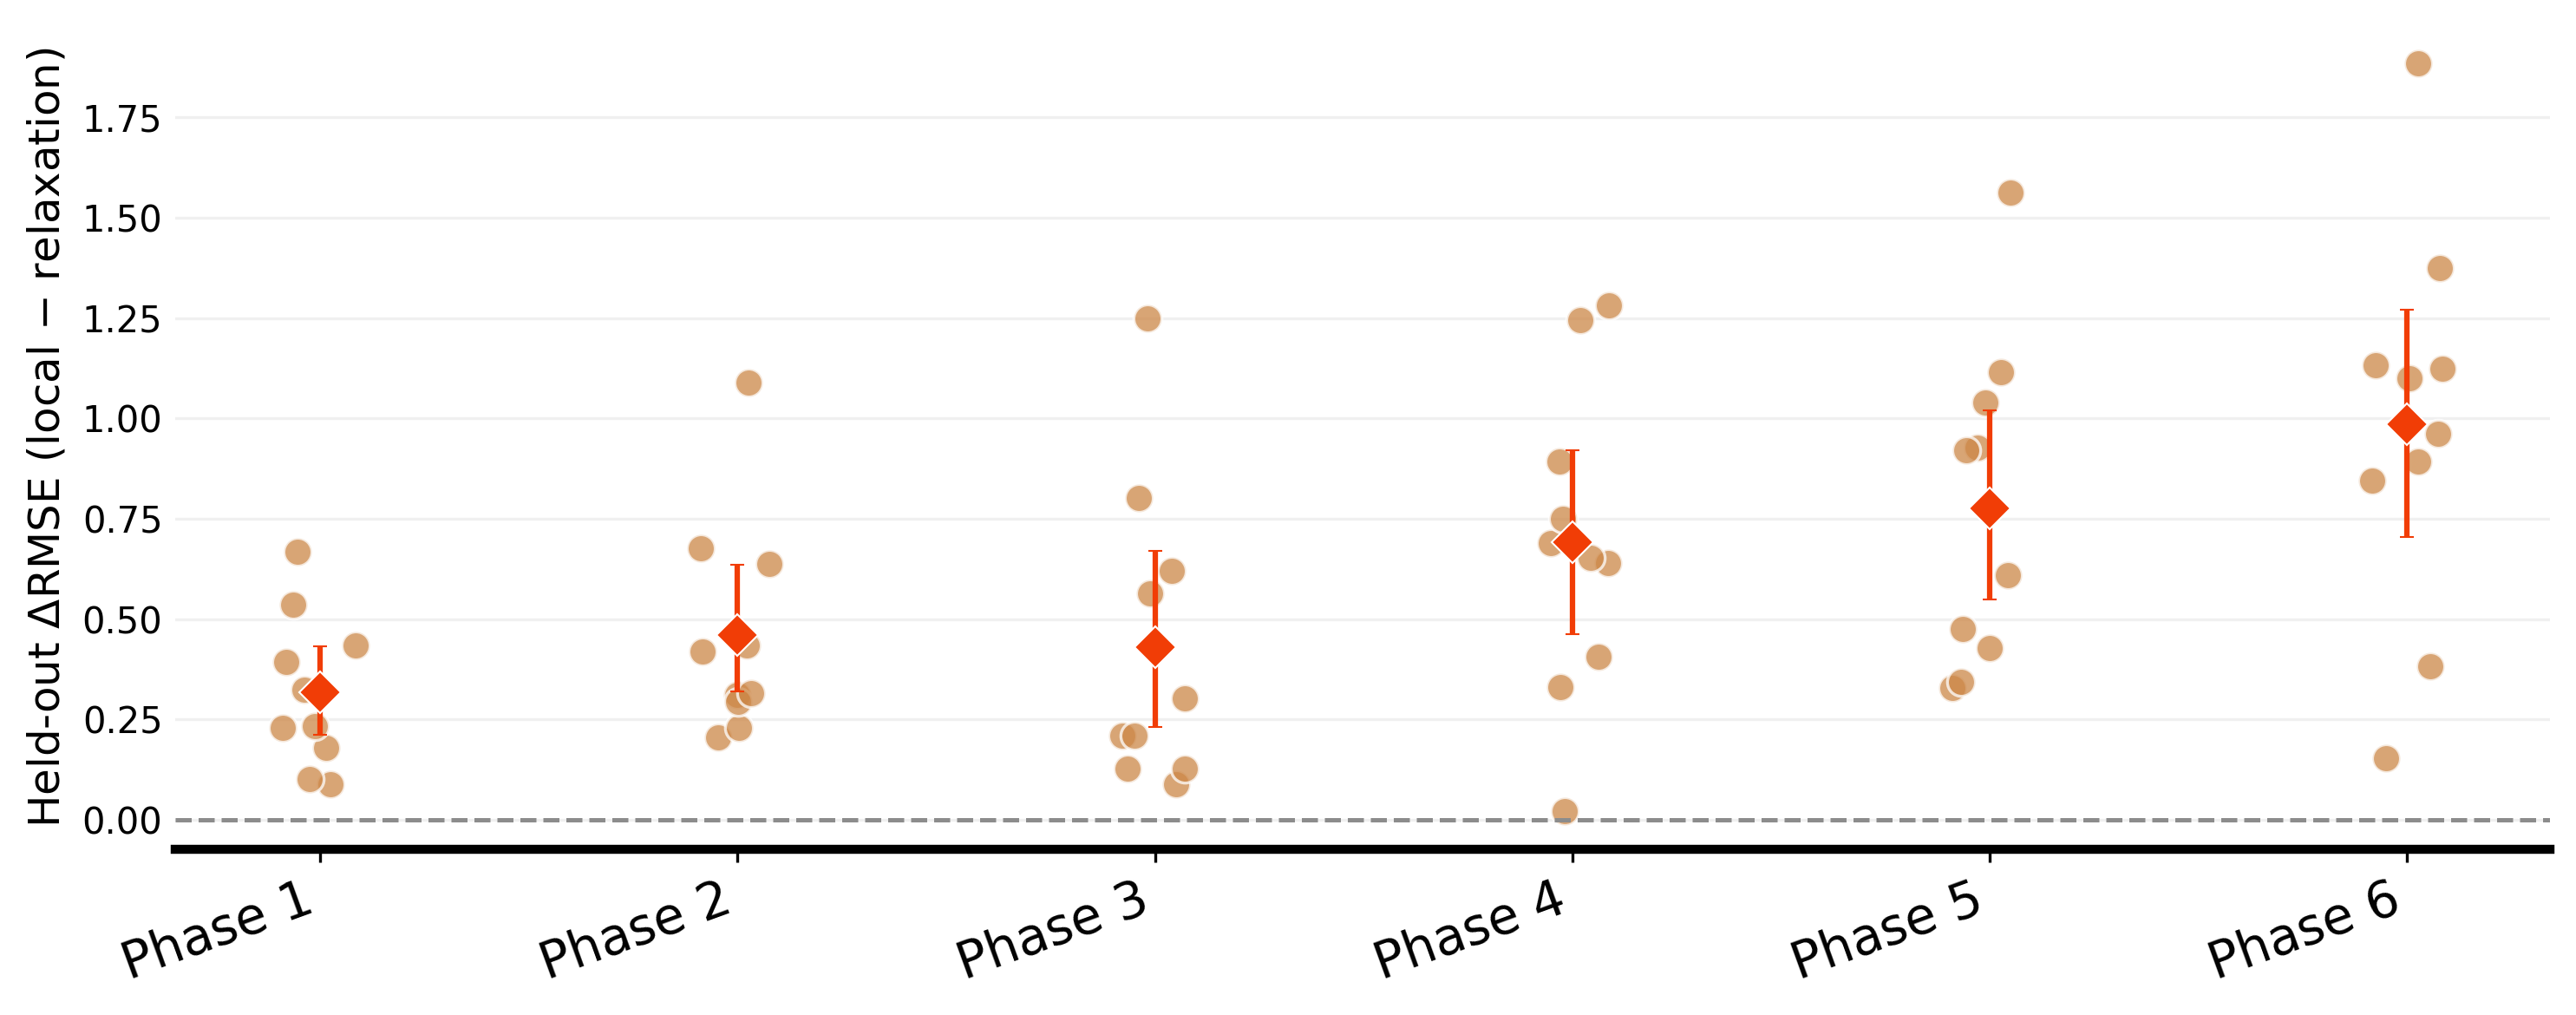

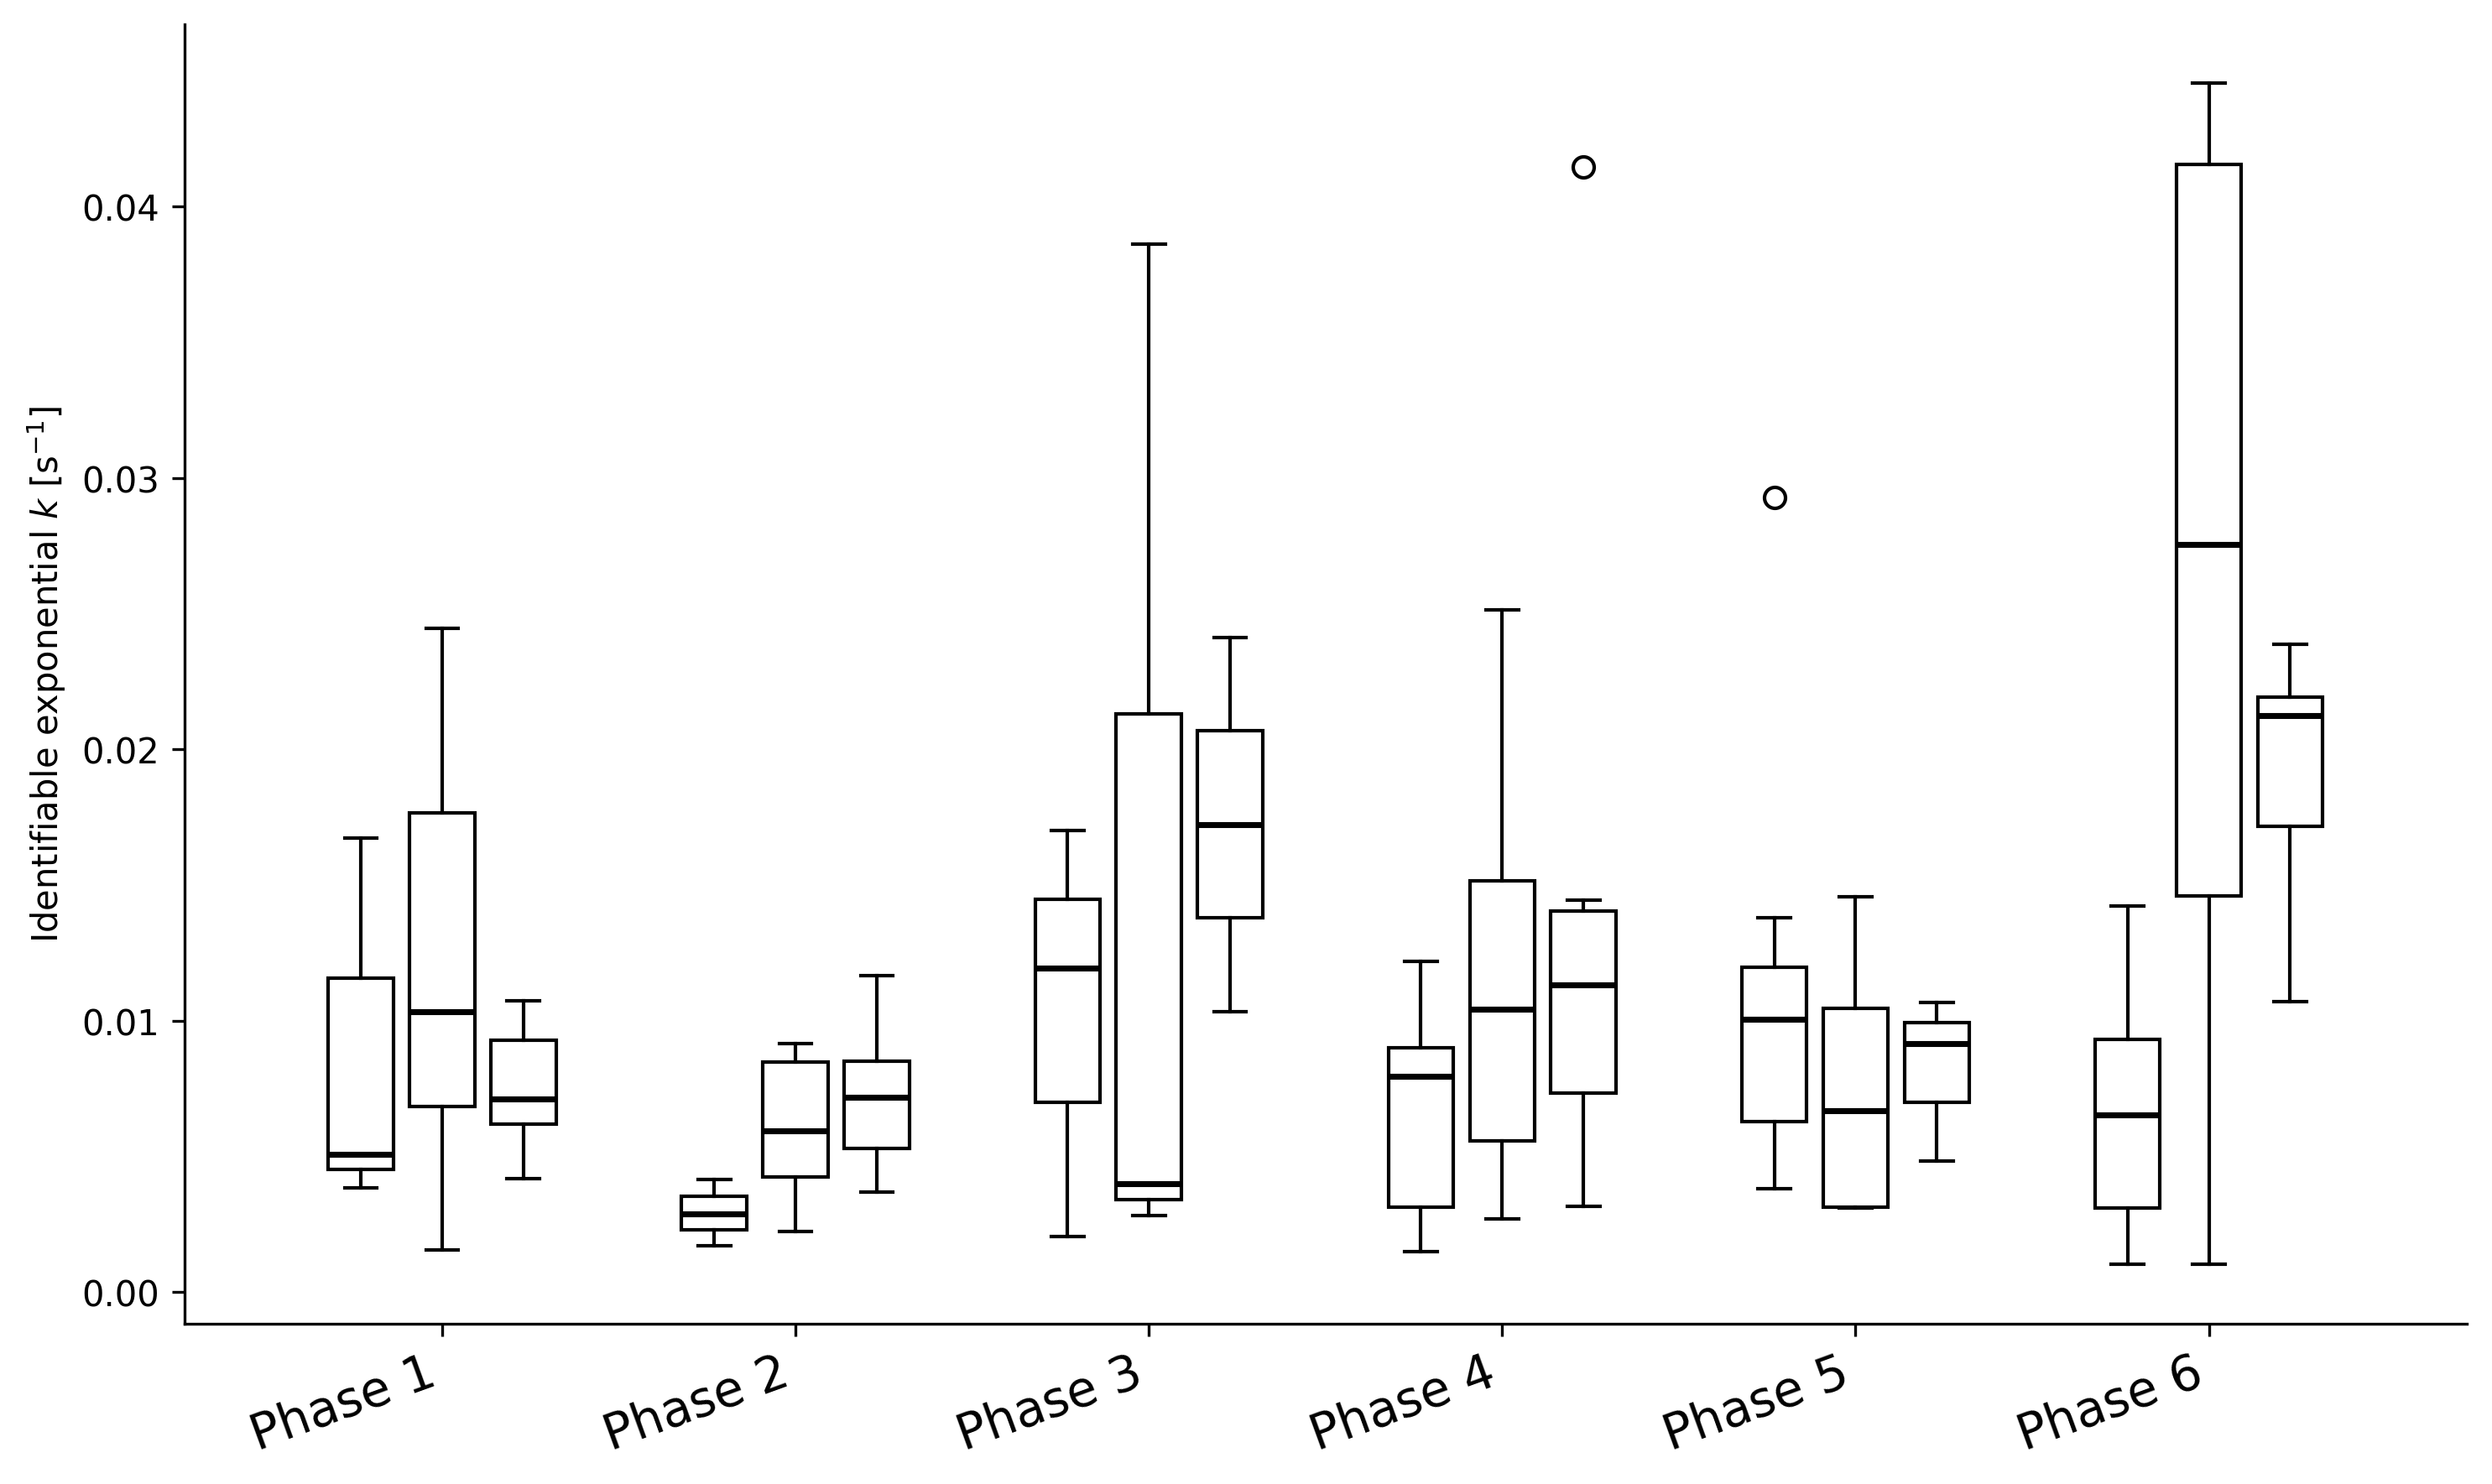

In [25]:
def clean_axis(axis):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


PHASE_LABELS_SHORT = {
    "standing_1": "Phase 1",
    "walk_low_1": "Phase 2",
    "walk_mod_1": "Phase 3",
    "walk_low_2": "Phase 4",
    "walk_mod_2": "Phase 5",
    "standing_2": "Phase 6",
}


# Primary transition-model comparison: participant-level paired values.
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
phase_positions = np.arange(len(PHASE_ORDER))
transition_plot_rng = np.random.default_rng(20260901)

for phase_index, phase in enumerate(PHASE_ORDER):
    values = transition_subject_phase_values.loc[
        transition_subject_phase_values[PHASE_COL] == phase,
        "mean_delta_rmse_C",
    ].to_numpy(dtype=float)
    jitter = transition_plot_rng.uniform(-0.09, 0.09, len(values))
    ax.scatter(
        np.full(len(values), phase_index) + jitter,
        values,
        s=60,
        facecolor="#cc8747",
        edgecolor="white",
        linewidth=0.8,
        alpha=0.75,
        zorder=2,
    )

phase_summary = (
    transition_phase_inference
    .set_index(PHASE_COL)
    .loc[PHASE_ORDER]
    .reset_index()
)
means = phase_summary["mean_delta_rmse_C"].to_numpy()
lower = means - phase_summary["ci_low_C"].to_numpy()
upper = phase_summary["ci_high_C"].to_numpy() - means

ax.errorbar(
    phase_positions,
    means,
    yerr=np.vstack([lower, upper]),
    fmt="D",
    color="#f13d06",
    markerfacecolor="#f13d06",
    markeredgecolor="white",
    markeredgewidth=0.5,
    markersize=8,
    capsize=2,
    linewidth=1.5,
    zorder=5,
)

ax.axhline(0, color="0.55", linewidth=1.2, linestyle="--")
ax.set_ylabel(
    r"Held-out $\Delta$RMSE (local $-$ relaxation)",
    fontsize=12
)
ax.set_xticks(phase_positions)
ax.set_xticklabels(
    [PHASE_LABELS_SHORT[phase] for phase in PHASE_ORDER],
    rotation=20,
    ha="right",
    fontsize=14
)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_linewidth(2.5)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", alpha=0.18, linewidth=0.8)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "transition_delta_rmse_by_phase.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Descriptive distribution of identifiable exponential k values.
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
phase_positions = np.arange(len(PHASE_ORDER))
width = 0.23
for condition_index, condition in enumerate(CONDITION_ORDER):
    values = [
        k_data.loc[
            (k_data[PHASE_COL] == phase)
            & (k_data[CONDITION_COL] == condition),
            "k_1_per_s",
        ].dropna().to_numpy()
        for phase in PHASE_ORDER
    ]
    ax.boxplot(
        values,
        positions=phase_positions + (condition_index - 1) * width,
        widths=width * 0.8,
        patch_artist=True,
        boxprops={"facecolor": "white", "edgecolor": "black"},
        medianprops={"color": "black", "linewidth": 1.7},
    )

ax.set_xticks(phase_positions)
ax.set_xticklabels(
    [PHASE_LABELS[phase] for phase in PHASE_ORDER],
    rotation=20,
    ha="right",
    fontsize=14
)
ax.set_ylabel(r"Identifiable exponential $k$ [s$^{-1}$]")
clean_axis(ax)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "exponential_k_by_phase_condition.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Output and interpretation checklist

- Table 3 comes only from `table3_final.csv` generated in Section 1.
- The global condition-by-phase test and the 12 phase-specific contrasts answer different questions and are both reported.
- A significant contrast in one phase and a non-significant contrast in another do not prove that those two effects differ.
- Positive ΔRMSE means that the exponential model predicts held-out samples more accurately.
- Prediction validity and (k)-identifiability are separate criteria.
- The reported mixed-model tests are asymptotic; with the small sample, estimates and confidence intervals should accompany p-values.


## 5. Sensitivity to the trajectory-analysis window

The matched within-trial comparison is repeated using the first 180, 300, 420 and 600 s of every phase. For every window, both models are fitted on the first 70% of the selected interval and evaluated on its final 30%. The models, parameter bounds, validity criteria and participant-level inference are otherwise unchanged. The 300-s analysis remains the primary specification; the other windows assess robustness to this analytical choice.

In [26]:
# ============================================================
# WINDOW-LENGTH SENSITIVITY ANALYSIS
# ============================================================

SENSITIVITY_WINDOWS_SECONDS = (180.0, 300.0, 420.0, 600.0)
PRIMARY_WINDOW_SECONDS = 300.0
MIN_TRAIN_POINTS_SENSITIVITY = 10
MIN_TEST_POINTS_SENSITIVITY = 5
MIN_WINDOW_COVERAGE = 0.95
SENSITIVITY_BOOTSTRAP_SEED = 20260904


def prepare_trials_for_window(data, window_seconds):
    """Construct complete phase-relative trials for one window length."""
    prepared = []
    exclusion_rows = []
    columns = [
        SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL,
        T_DORSAL_COL, T_MICRO_COL,
    ]

    for keys, group in data.groupby(
        [SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True
    ):
        subject, condition, phase = keys
        reason = None
        trial = (
            group[columns]
            .dropna(subset=[TIME_COL])
            .sort_values(TIME_COL)
            .copy()
        )
        trial = trial.groupby(TIME_COL, as_index=False, observed=True).agg({
            SUBJECT_COL: "first",
            CONDITION_COL: "first",
            PHASE_COL: "first",
            T_DORSAL_COL: "mean",
            T_MICRO_COL: "mean",
        })

        if trial.empty:
            reason = "empty_trial"
        else:
            trial["time_s"] = trial[TIME_COL] - trial[TIME_COL].iloc[0]
            trial = trial[trial["time_s"].between(0, window_seconds)].copy()
            trial[T_DORSAL_COL] = interpolate_short_internal_gaps(
                trial[T_DORSAL_COL]
            )
            trial[T_MICRO_COL] = interpolate_short_internal_gaps(
                trial[T_MICRO_COL]
            )
            trial = (
                trial.dropna(subset=[T_DORSAL_COL, T_MICRO_COL])
                .drop_duplicates("time_s")
                .reset_index(drop=True)
            )

            if trial.empty:
                reason = "no_complete_observations"
            elif trial["time_s"].iloc[-1] < MIN_WINDOW_COVERAGE * window_seconds:
                reason = "insufficient_window_coverage"
            elif (
                trial[T_DORSAL_COL].max() - trial[T_DORSAL_COL].min()
                < MIN_TEMPERATURE_RANGE_C
            ):
                reason = "insufficient_temperature_range"
            else:
                t = trial["time_s"].to_numpy(dtype=float)
                cutoff = t[0] + TRAIN_FRACTION * (t[-1] - t[0])
                n_train = int(np.sum(t <= cutoff))
                n_test = int(np.sum(t > cutoff))
                if n_train < MIN_TRAIN_POINTS_SENSITIVITY:
                    reason = "insufficient_training_points"
                elif n_test < MIN_TEST_POINTS_SENSITIVITY:
                    reason = "insufficient_test_points"

        if reason is not None:
            exclusion_rows.append({
                "window_seconds": window_seconds,
                SUBJECT_COL: subject,
                CONDITION_COL: str(condition),
                PHASE_COL: str(phase),
                "exclusion_reason": reason,
            })
            continue

        trial["trial_id"] = "|".join(map(str, keys))
        prepared.append(trial)

    prepared_data = (
        pd.concat(prepared, ignore_index=True)
        if prepared else pd.DataFrame()
    )
    return prepared_data, pd.DataFrame(exclusion_rows)


sensitivity_fit_tables = []
sensitivity_exclusion_tables = []

for sensitivity_window in SENSITIVITY_WINDOWS_SECONDS:
    print(f"Running trajectory comparison: first {sensitivity_window:.0f} s")
    window_trial_data, window_exclusions = prepare_trials_for_window(
        dynamic_raw, sensitivity_window
    )
    if window_trial_data.empty:
        print("  No eligible trials.")
        continue

    window_fit_results, _ = fit_all_trials(window_trial_data)
    window_fit_results.insert(0, "window_seconds", sensitivity_window)
    sensitivity_fit_tables.append(window_fit_results)

    if not window_exclusions.empty:
        sensitivity_exclusion_tables.append(window_exclusions)

sensitivity_fit_results = pd.concat(
    sensitivity_fit_tables, ignore_index=True
)
sensitivity_trial_exclusions = (
    pd.concat(sensitivity_exclusion_tables, ignore_index=True)
    if sensitivity_exclusion_tables else pd.DataFrame()
)

sensitivity_fit_results.to_csv(
    OUTPUT_DIR / "transition_window_sensitivity_fit_results.csv",
    index=False,
)
sensitivity_trial_exclusions.to_csv(
    OUTPUT_DIR / "transition_window_sensitivity_exclusions.csv",
    index=False,
)


Running trajectory comparison: first 180 s
Running trajectory comparison: first 300 s
Running trajectory comparison: first 420 s
Running trajectory comparison: first 600 s


In [27]:
# ============================================================
# PARTICIPANT-LEVEL INFERENCE FOR EVERY WINDOW
# ============================================================

sensitivity_rng = np.random.default_rng(SENSITIVITY_BOOTSTRAP_SEED)


def sensitivity_bootstrap_mean_ci(values, n_bootstrap=N_BOOTSTRAP_TRANSITION):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    samples = sensitivity_rng.choice(
        values, size=(n_bootstrap, len(values)), replace=True
    )
    return tuple(np.quantile(samples.mean(axis=1), [0.025, 0.975]))


valid_sensitivity = sensitivity_fit_results.loc[
    sensitivity_fit_results["prediction_valid"]
    & np.isfinite(sensitivity_fit_results["rmse_test"])
].copy()

sensitivity_paired_trials = (
    valid_sensitivity
    .pivot(
        index=[
            "window_seconds", "trial_id", SUBJECT_COL,
            CONDITION_COL, PHASE_COL,
        ],
        columns="model",
        values="rmse_test",
    )
    .dropna(subset=["exponential", "local_balance"])
    .reset_index()
)
sensitivity_paired_trials["delta_rmse_C"] = (
    sensitivity_paired_trials["local_balance"]
    - sensitivity_paired_trials["exponential"]
)

sensitivity_subject_values = (
    sensitivity_paired_trials
    .groupby(["window_seconds", SUBJECT_COL], observed=True)
    .agg(
        mean_delta_rmse_C=("delta_rmse_C", "mean"),
        median_delta_rmse_C=("delta_rmse_C", "median"),
        n_trials=("trial_id", "nunique"),
    )
    .reset_index()
)

overall_rows = []
phase_rows = []
subject_phase_tables = []

for sensitivity_window in SENSITIVITY_WINDOWS_SECONDS:
    subject_subset = sensitivity_subject_values.loc[
        sensitivity_subject_values["window_seconds"] == sensitivity_window
    ]
    values = subject_subset["mean_delta_rmse_C"].to_numpy(dtype=float)
    ci_low, ci_high = sensitivity_bootstrap_mean_ci(values)
    trial_subset = sensitivity_paired_trials.loc[
        sensitivity_paired_trials["window_seconds"] == sensitivity_window
    ]
    overall_rows.append({
        "window_seconds": sensitivity_window,
        "n_paired_trials": len(trial_subset),
        "n_subjects": len(values),
        "mean_delta_rmse_C": np.mean(values),
        "median_delta_rmse_C": np.median(values),
        "ci_low_C": ci_low,
        "ci_high_C": ci_high,
        "subjects_relaxation_better": int(np.sum(values > 0)),
        "subjects_local_balance_better": int(np.sum(values < 0)),
        "proportion_trials_relaxation_better": np.mean(
            trial_subset["delta_rmse_C"] > 0
        ),
        "p_sign_flip": exact_sign_flip_test(values),
    })

    subject_phase = (
        trial_subset
        .groupby([SUBJECT_COL, PHASE_COL], observed=True)
        .agg(
            mean_delta_rmse_C=("delta_rmse_C", "mean"),
            median_delta_rmse_C=("delta_rmse_C", "median"),
            n_conditions=(CONDITION_COL, "nunique"),
        )
        .reset_index()
    )
    subject_phase.insert(0, "window_seconds", sensitivity_window)
    subject_phase_tables.append(subject_phase)

    current_phase_rows = []
    for phase in PHASE_ORDER:
        phase_values = subject_phase.loc[
            subject_phase[PHASE_COL] == phase,
            "mean_delta_rmse_C",
        ].to_numpy(dtype=float)
        phase_ci_low, phase_ci_high = sensitivity_bootstrap_mean_ci(
            phase_values
        )
        current_phase_rows.append({
            "window_seconds": sensitivity_window,
            PHASE_COL: phase,
            "n_subjects": len(phase_values),
            "mean_delta_rmse_C": np.mean(phase_values),
            "median_delta_rmse_C": np.median(phase_values),
            "ci_low_C": phase_ci_low,
            "ci_high_C": phase_ci_high,
            "subjects_relaxation_better": int(np.sum(phase_values > 0)),
            "subjects_local_balance_better": int(np.sum(phase_values < 0)),
            "p_raw": exact_sign_flip_test(phase_values),
        })

    current_phase = pd.DataFrame(current_phase_rows)
    current_phase["p_holm"] = multipletests(
        current_phase["p_raw"], method="holm"
    )[1]
    phase_rows.extend(current_phase.to_dict(orient="records"))

sensitivity_overall_inference = pd.DataFrame(overall_rows)
sensitivity_subject_phase_values = pd.concat(
    subject_phase_tables, ignore_index=True
)
sensitivity_phase_inference = pd.DataFrame(phase_rows)

sensitivity_paired_trials.to_csv(
    OUTPUT_DIR / "transition_window_sensitivity_trial_values.csv",
    index=False,
)
sensitivity_subject_values.to_csv(
    OUTPUT_DIR / "transition_window_sensitivity_subject_values.csv",
    index=False,
)
sensitivity_subject_phase_values.to_csv(
    OUTPUT_DIR / "transition_window_sensitivity_subject_phase_values.csv",
    index=False,
)
sensitivity_overall_inference.to_csv(
    OUTPUT_DIR / "transition_window_sensitivity_overall_inference.csv",
    index=False,
)
sensitivity_phase_inference.to_csv(
    OUTPUT_DIR / "transition_window_sensitivity_phase_inference.csv",
    index=False,
)

print("\nWindow-sensitivity overall inference:")
display(sensitivity_overall_inference)
print("\nWindow-sensitivity phase inference:")
display(sensitivity_phase_inference)
print("\nTrial exclusions by window and reason:")
if sensitivity_trial_exclusions.empty:
    print("None")
else:
    display(
        sensitivity_trial_exclusions
        .groupby(["window_seconds", "exclusion_reason"], observed=True)
        .size()
        .rename("n_trials")
        .reset_index()
    )



Window-sensitivity overall inference:


,window_seconds,n_paired_trials,n_subjects,mean_delta_rmse_C,median_delta_rmse_C,ci_low_C,ci_high_C,subjects_relaxation_better,subjects_local_balance_better,proportion_trials_relaxation_better,p_sign_flip
0,180.0,171,10,0.239742,0.218653,0.182632,0.300062,10,0,0.783626,0.001953
1,300.0,179,10,0.605533,0.587918,0.505463,0.706470,10,0,0.921788,0.001953
2,420.0,179,10,0.760124,0.820326,0.627188,0.888073,10,0,0.938547,0.001953
3,600.0,180,10,0.824107,0.811017,0.672739,0.976751,10,0,0.933333,0.001953



Window-sensitivity phase inference:


,window_seconds,phase,n_subjects,mean_delta_rmse_C,median_delta_rmse_C,ci_low_C,ci_high_C,subjects_relaxation_better,subjects_local_balance_better,p_raw,p_holm
0,180.0,standing_1,10,0.121908,0.081468,0.055261,0.210163,10,0,0.001953,0.011719
1,180.0,walk_low_1,10,0.213812,0.191416,0.132976,0.298972,10,0,0.001953,0.011719
2,180.0,walk_mod_1,10,0.135761,0.048674,0.033356,0.261154,10,0,0.001953,0.011719
3,180.0,walk_low_2,10,0.237753,0.188259,0.096317,0.423808,8,2,0.007812,0.015625
4,180.0,walk_mod_2,10,0.214097,0.051635,0.036058,0.510117,9,1,0.011719,0.015625
5,180.0,standing_2,10,0.547039,0.504211,0.293796,0.834578,10,0,0.001953,0.011719
6,300.0,standing_1,10,0.318379,0.278657,0.210351,0.433534,10,0,0.001953,0.011719
7,300.0,walk_low_1,10,0.461346,0.367305,0.320231,0.633903,10,0,0.001953,0.011719
8,300.0,walk_mod_1,10,0.430079,0.255874,0.227753,0.670178,10,0,0.001953,0.011719
9,300.0,walk_low_2,10,0.690753,0.670706,0.463025,0.919314,10,0,0.001953,0.011719



Trial exclusions by window and reason:


,window_seconds,exclusion_reason,n_trials
0,180.0,insufficient_temperature_range,7


## 6. Relaxation-parameter distributions

Parameter summaries and the figure below include only relaxation fits satisfying the joint identifiability criteria for $\tau$ and $T_{\mathrm{eq}}$. Prediction-valid but non-identifiable fits remain in the RMSE comparison and are excluded only from physical parameter interpretation.

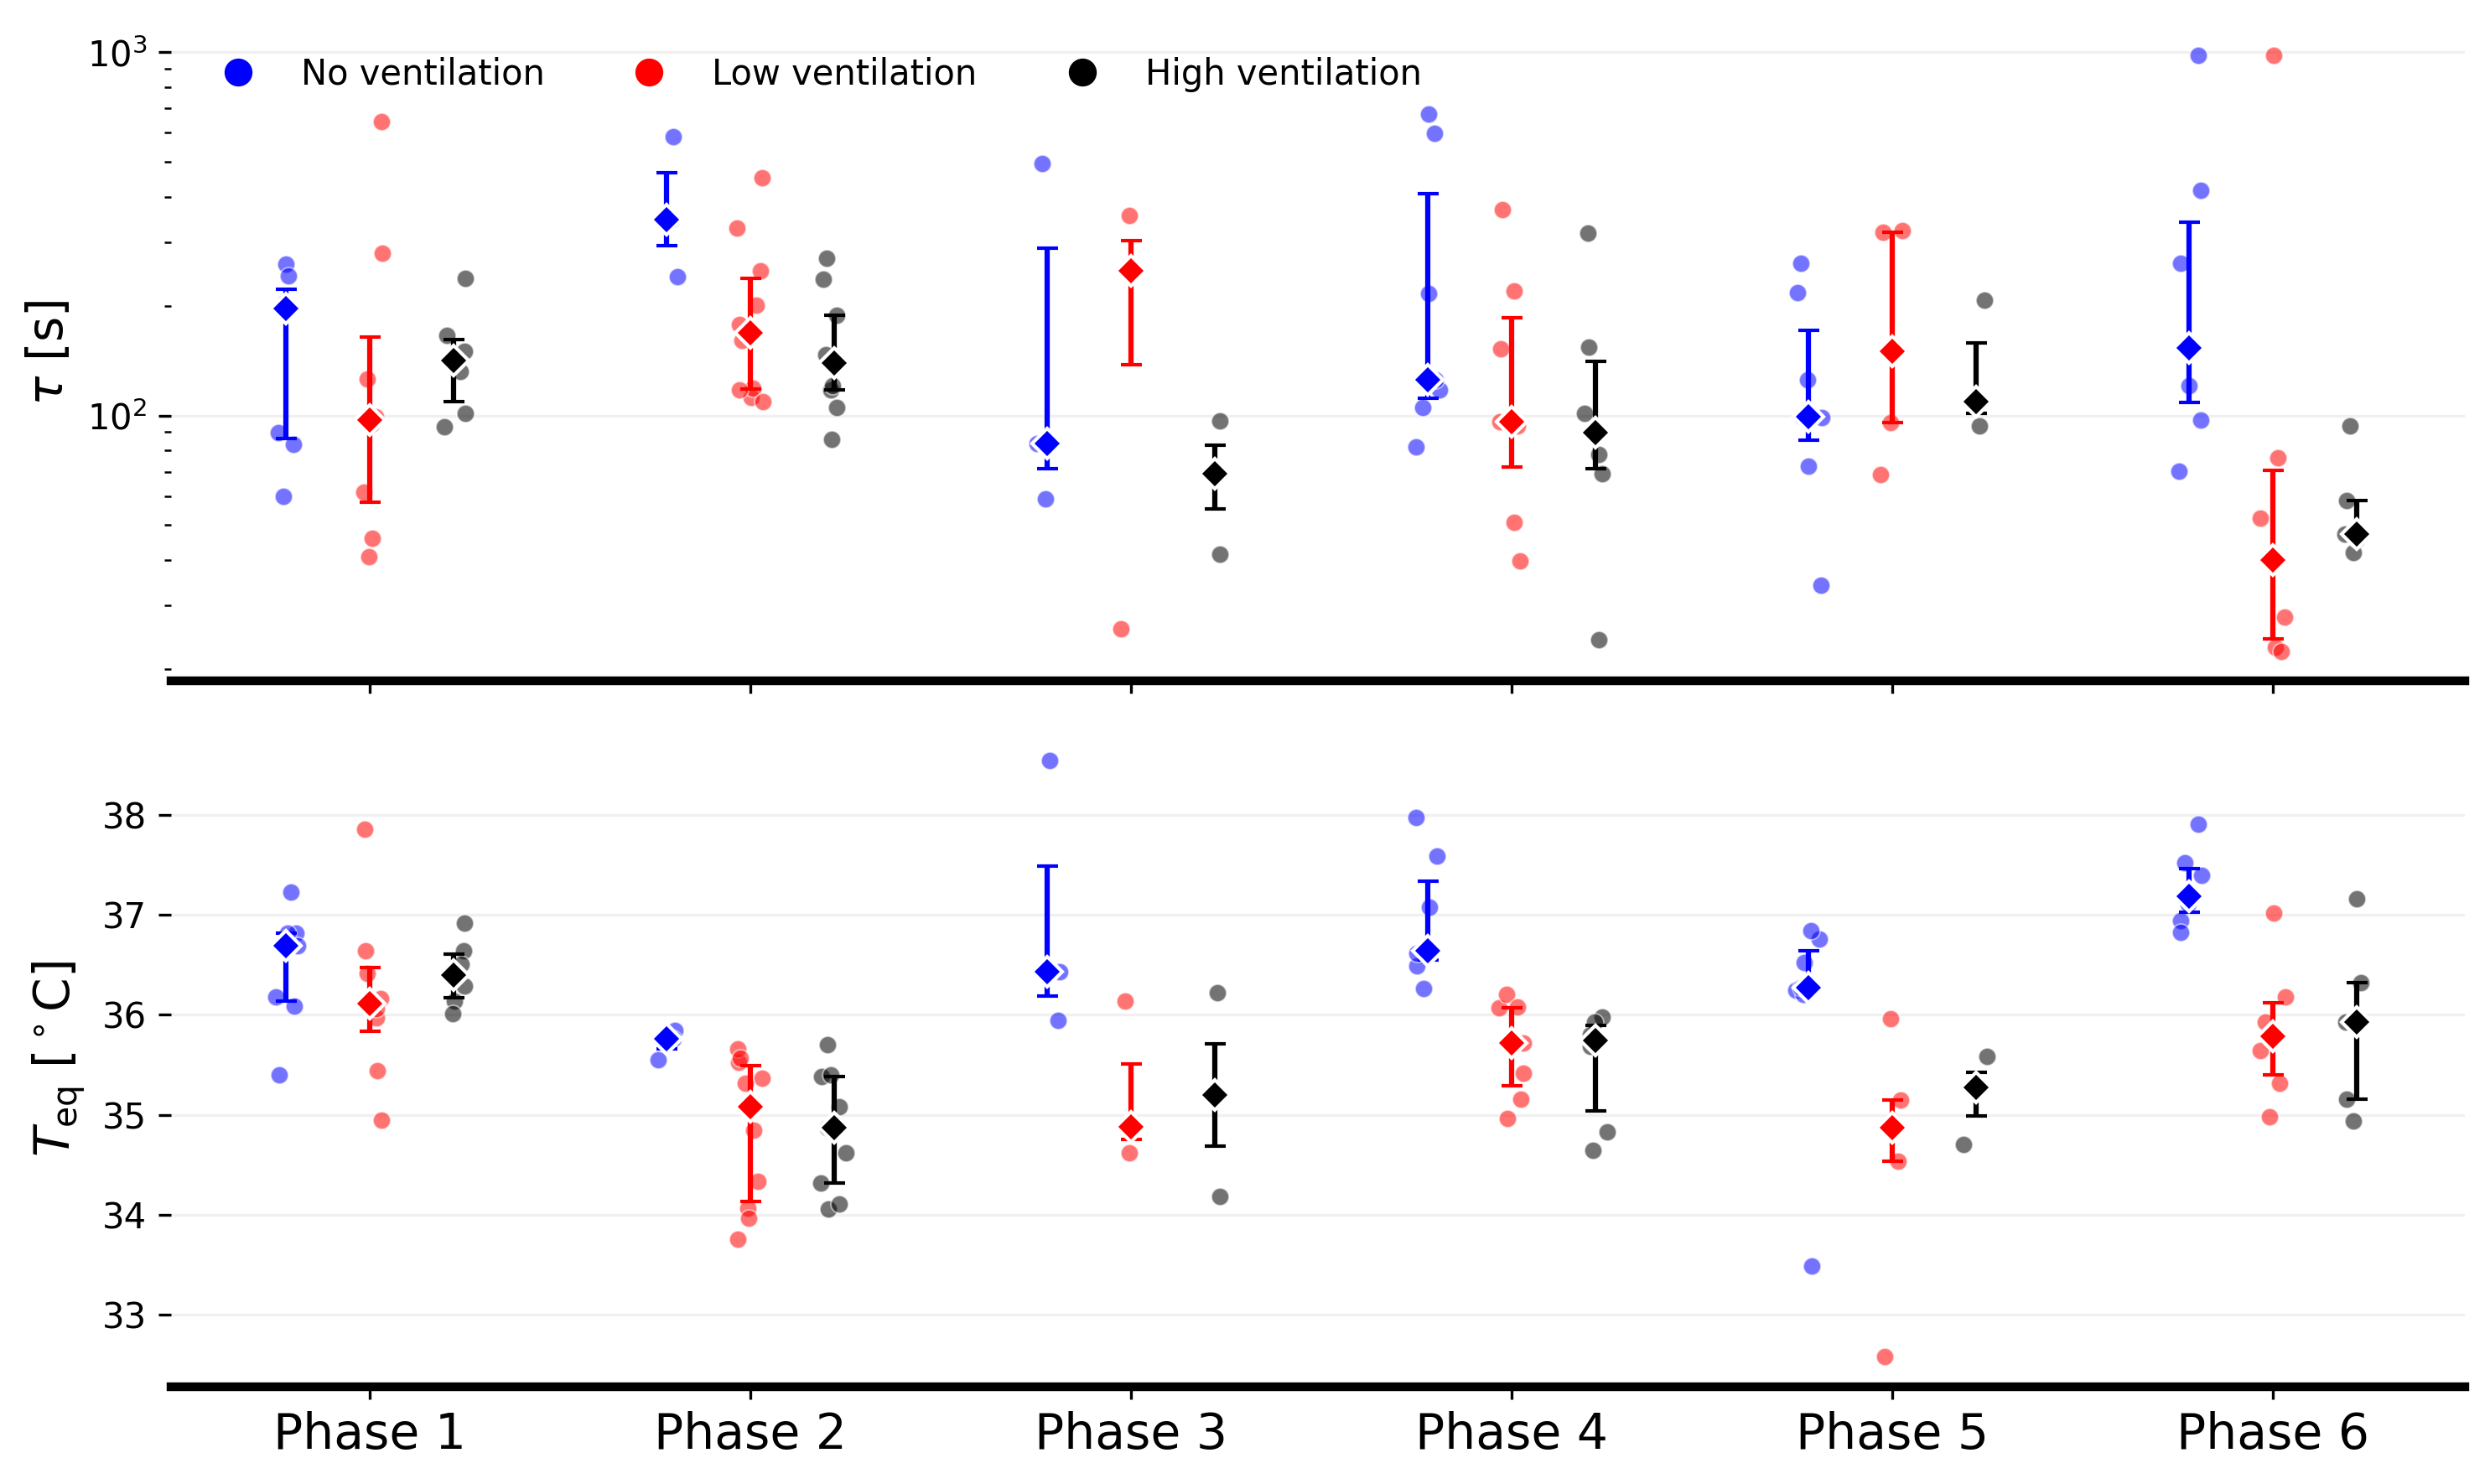

Relaxation fits: 180
Jointly identifiable fits: 104


,phase,condition,n_fits,n_prediction_valid,n_parameter_identifiable,proportion_parameter_identifiable,n_tau_at_bound,n_Teq_at_bound,median_tau_s,q25_tau_s,q75_tau_s,median_Teq_C,q25_Teq_C,q75_Teq_C
0,standing_1,no_wind,10,10,7,0.7,3,0,197.315115,86.582863,222.977982,36.691889,36.135457,36.820407
1,standing_1,wind_low,10,10,8,0.8,2,0,96.978371,57.615044,164.598661,36.112321,35.835006,36.474489
2,standing_1,wind_high,10,10,6,0.6,3,0,141.393125,109.175469,162.126018,36.397270,36.175141,36.610002
3,walk_low_1,no_wind,10,10,3,0.3,6,0,346.703394,293.795408,465.533549,35.760780,35.657607,35.801863
4,walk_low_1,wind_low,10,10,10,1.0,0,0,169.172824,118.016918,238.399192,35.080377,34.135473,35.488478
5,walk_low_1,wind_high,10,10,9,0.9,1,0,139.220902,117.579576,188.873451,34.867947,34.320155,35.386916
6,walk_mod_1,no_wind,10,10,3,0.3,7,0,83.688578,71.234965,288.367822,36.435863,36.189921,37.490210
7,walk_mod_1,wind_low,10,10,3,0.3,6,0,250.066075,137.979208,302.336692,34.882387,34.752717,35.508992
8,walk_mod_1,wind_high,10,10,2,0.2,5,0,69.132242,55.285455,82.979030,35.199851,34.690072,35.709630
9,walk_low_2,no_wind,10,10,7,0.7,3,0,125.668319,111.396563,407.843381,36.638002,36.551863,37.335253


Figure saved to: /home/eleonorab/repository/convective_cooling/reports/06_statistics/final_analysis/relaxation_parameter_distributions.png


In [34]:
# ============================================================
# RELAXATION-PARAMETER SUMMARY AND FIGURE
# ============================================================

relaxation_all = fit_results.loc[
    fit_results["model"] == "exponential"
].copy()
relaxation_identifiable = relaxation_all.loc[
    relaxation_all["parameter_identifiable"]
    & np.isfinite(relaxation_all["tau_s"])
    & np.isfinite(relaxation_all["Teq_C"])
].copy()

parameter_rows = []
for phase in PHASE_ORDER:
    for condition in CONDITION_ORDER:
        all_group = relaxation_all.loc[
            (relaxation_all[PHASE_COL] == phase)
            & (relaxation_all[CONDITION_COL] == condition)
        ]
        valid_group = relaxation_identifiable.loc[
            (relaxation_identifiable[PHASE_COL] == phase)
            & (relaxation_identifiable[CONDITION_COL] == condition)
        ]
        parameter_rows.append({
            PHASE_COL: phase,
            CONDITION_COL: condition,
            "n_fits": len(all_group),
            "n_prediction_valid": int(all_group["prediction_valid"].sum()),
            "n_parameter_identifiable": len(valid_group),
            "proportion_parameter_identifiable": (
                len(valid_group) / len(all_group) if len(all_group) else np.nan
            ),
            "n_tau_at_bound": int(all_group["tau_at_bound"].fillna(False).sum()),
            "n_Teq_at_bound": int(all_group["Teq_at_bound"].fillna(False).sum()),
            "median_tau_s": valid_group["tau_s"].median(),
            "q25_tau_s": valid_group["tau_s"].quantile(0.25),
            "q75_tau_s": valid_group["tau_s"].quantile(0.75),
            "median_Teq_C": valid_group["Teq_C"].median(),
            "q25_Teq_C": valid_group["Teq_C"].quantile(0.25),
            "q75_Teq_C": valid_group["Teq_C"].quantile(0.75),
        })

relaxation_parameter_summary = pd.DataFrame(parameter_rows)
relaxation_parameter_summary.to_csv(
    OUTPUT_DIR / "relaxation_parameter_summary.csv", index=False
)
relaxation_identifiable.to_csv(
    OUTPUT_DIR / "relaxation_identifiable_fits.csv", index=False
)

condition_colors = {
    "no_wind": "blue",
    "wind_low": "red",
    "wind_high": "black",
}
offsets = {"no_wind": -0.22, "wind_low": 0.0, "wind_high": 0.22}
parameter_rng = np.random.default_rng(20260907)
x = np.arange(len(PHASE_ORDER), dtype=float)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=300, sharex=True)
for ax, variable, ylabel, use_log in [
    (axes[0], "tau_s", r"$\tau$ [s]", True),
    (axes[1], "Teq_C", r"$T_{\mathrm{eq}}$ [$^\circ$C]", False),
]:
    for condition in CONDITION_ORDER:
        color = condition_colors[condition]
        for phase_index, phase in enumerate(PHASE_ORDER):
            values = relaxation_identifiable.loc[
                (relaxation_identifiable[PHASE_COL] == phase)
                & (relaxation_identifiable[CONDITION_COL] == condition),
                variable,
            ].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue
            xpos = phase_index + offsets[condition]
            jitter = parameter_rng.uniform(-0.035, 0.035, len(values))
            ax.scatter(
                xpos + jitter, values, s=25, color=color, alpha=0.55,
                edgecolor="white", linewidth=0.45, zorder=2,
            )
            median = np.median(values)
            q25, q75 = np.quantile(values, [0.25, 0.75])
            ax.errorbar(
                xpos, median, yerr=[[median - q25], [q75 - median]],
                fmt="D", color=color, markeredgecolor="white",
                markersize=6, capsize=3, linewidth=1.5, zorder=3,
            )
    if use_log:
        ax.set_yscale("log")
    ax.set_ylabel(ylabel, fontsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.grid(axis="y", alpha=0.18, linewidth=0.8)

legend_handles = [
    plt.Line2D(
        [0], [0], marker="o", linestyle="none",
        color=condition_colors[c], label=CONDITION_LABELS[c], markersize=7,
    )
    for c in CONDITION_ORDER
]
axes[0].legend(handles=legend_handles, frameon=False, ncol=3, loc="upper left")
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(
    [PHASE_LABELS[phase] for phase in PHASE_ORDER], fontsize=14
)
plt.tight_layout()
parameter_figure_path = OUTPUT_DIR / "relaxation_parameter_distributions.png"
fig.savefig(parameter_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Relaxation fits:", len(relaxation_all))
print("Jointly identifiable fits:", len(relaxation_identifiable))
display(relaxation_parameter_summary)
print("Figure saved to:", parameter_figure_path)
